# EDA

This notebook performs the Exploratory Data Analysis (EDA) to understand the main characteristics of the dataset before transformations and modeling. 

It examines both categorical and numerical variables through descriptive statistics and visualizations, helping to detect patterns, trends, and potential data issues. 

The goal is to gain a clear understanding of the dataset’s behavior and prepare insights that will guide the following preprocessing and feature engineering stages.

## Load data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Path to the calibrated working dataset
path = '/Users/rober/retail-stockout-risk-scoring/02_Data/03_Working/'
file_name = 'retail_store_inventory_PRO_WORKING.csv'

df = pd.read_csv(path + file_name)
print(f"Dataset loaded: {len(df)} rows and {len(df.columns)} columns.")

Dataset loaded: 51170 rows and 15 columns.


## Target definition

In [14]:
# Defining the 14-day lead time target for analysis
days_window = 14
df['target'] = (df['Inventory Level'] < (df['Units Sold'] * days_window)).astype(int)

print("Target Distribution (Counts):")
print(df['target'].value_counts())
print(f"\nTarget Ratio: {df['target'].mean()*100:.2f}%")

Target Distribution (Counts):
target
0    43497
1     7673
Name: count, dtype: int64

Target Ratio: 15.00%


## Variable Separation

In [15]:
# Separating predictors by data type to apply specific analytical treatments
target = 'target'
cat = df.select_dtypes(include=['object', 'category']).columns.tolist()
num = df.select_dtypes(include=['number']).columns.tolist()

if target in num: num.remove(target)

print(f"Categorical features: {cat}")
print(f"Numerical features: {num}")

Categorical features: ['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']
Numerical features: ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']


## Numerical distribution and risk profiling

                      count         mean          std    min          25%  \
Inventory Level     51170.0  3725.648933  3234.116866   0.00  1154.015815   
Units Sold          51170.0   136.471898   108.893438   0.00    48.000000   
Units Ordered       51170.0   109.861833    52.281521  20.00    65.000000   
Demand Forecast     51170.0   141.497783   109.217860  -9.99    53.620000   
Price               51170.0    54.932099    26.007676  10.00    32.460000   
Discount            51170.0     9.993160     7.099681   0.00     5.000000   
Holiday/Promotion   51170.0     0.497264     0.499997   0.00     0.000000   
Competitor Pricing  51170.0    54.946521    26.185425   5.03    32.480000   

                         50%      75%       max  
Inventory Level     2689.000  5560.00  15148.00  
Units Sold           107.000   203.00    499.00  
Units Ordered        110.000   155.00    200.00  
Demand Forecast      112.945   208.17    518.55  
Price                 54.720    77.69    100.00  
Discou

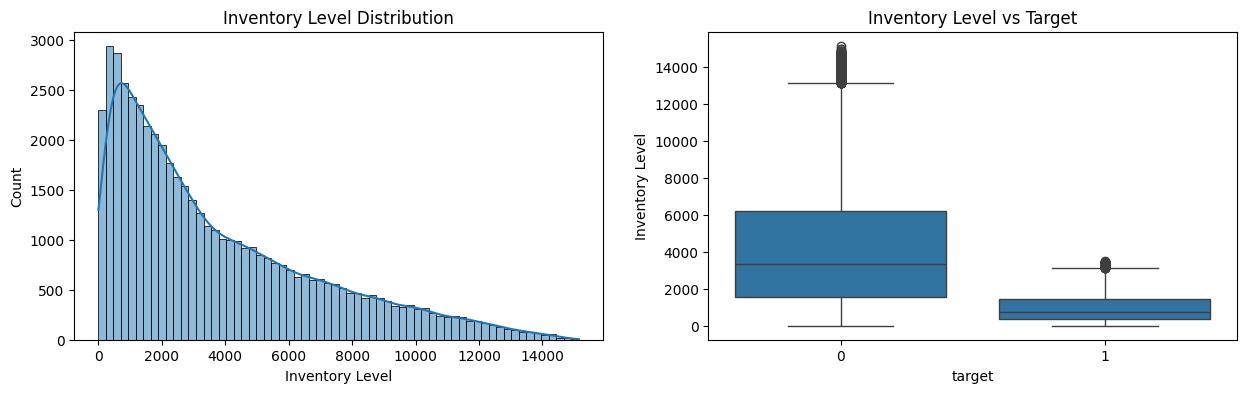

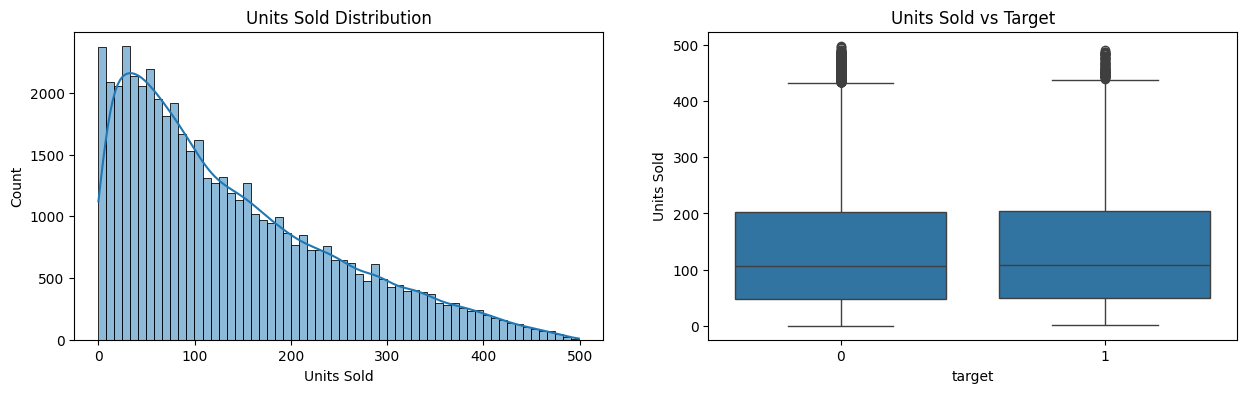

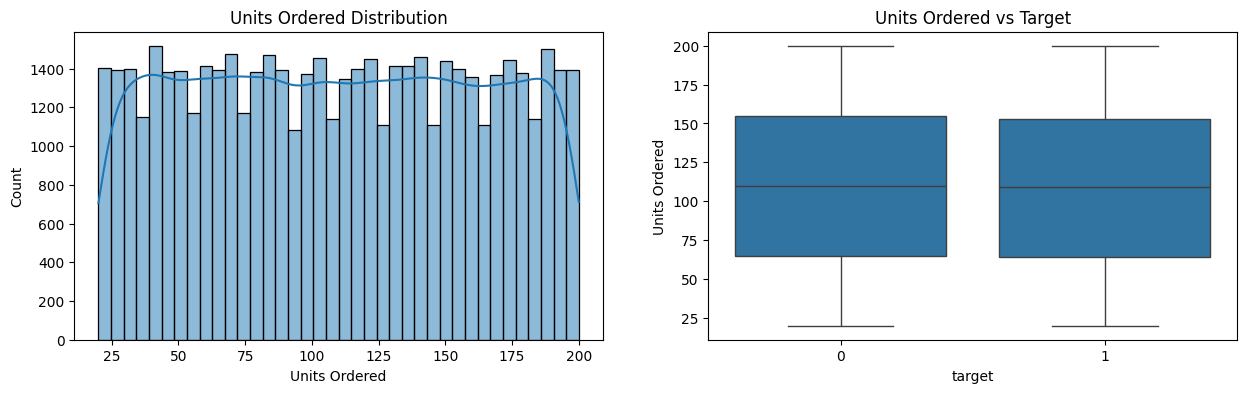

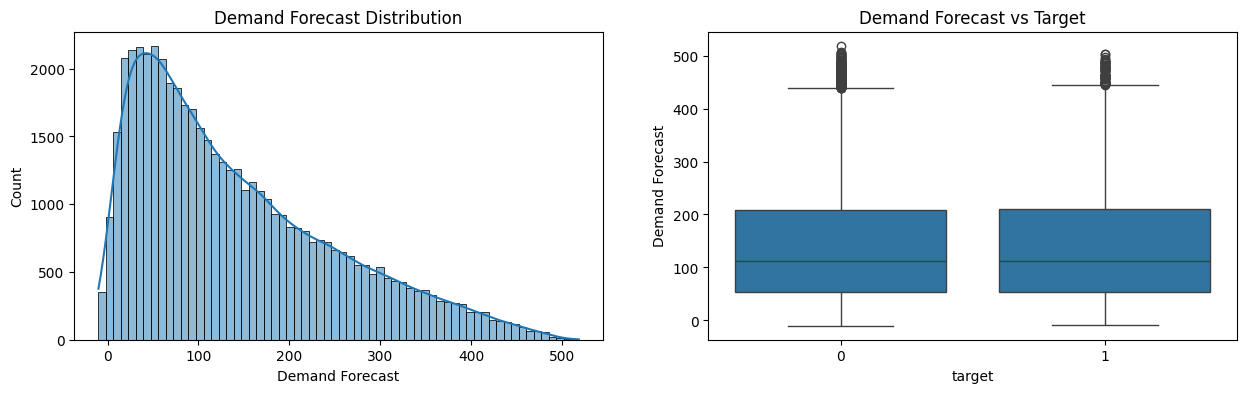

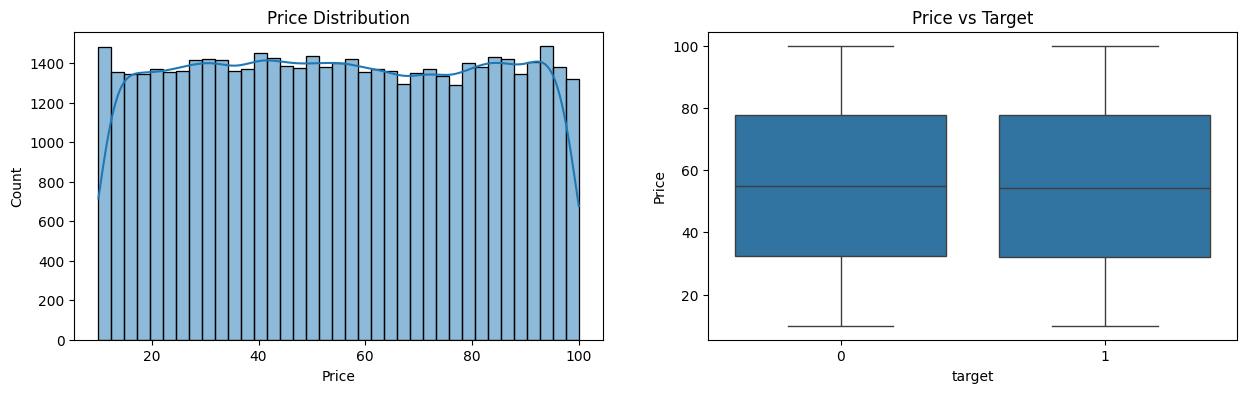

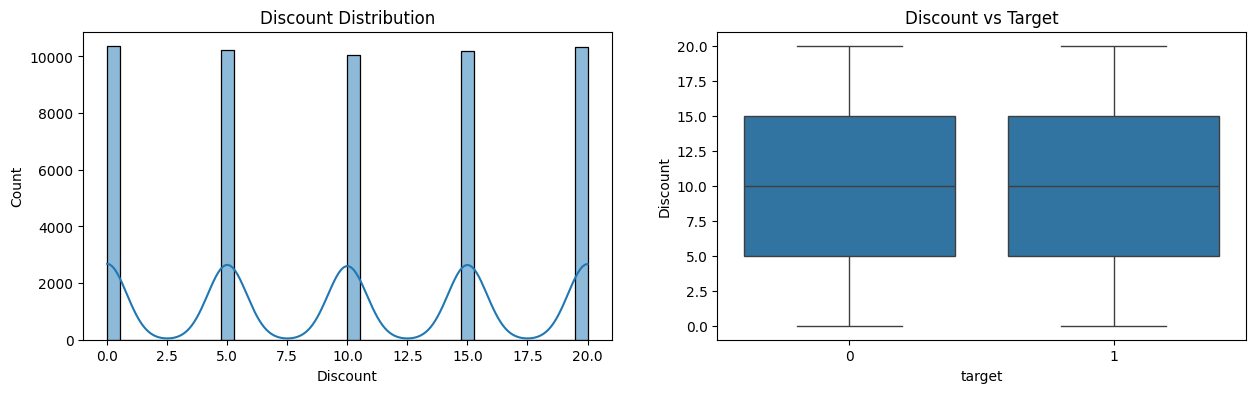

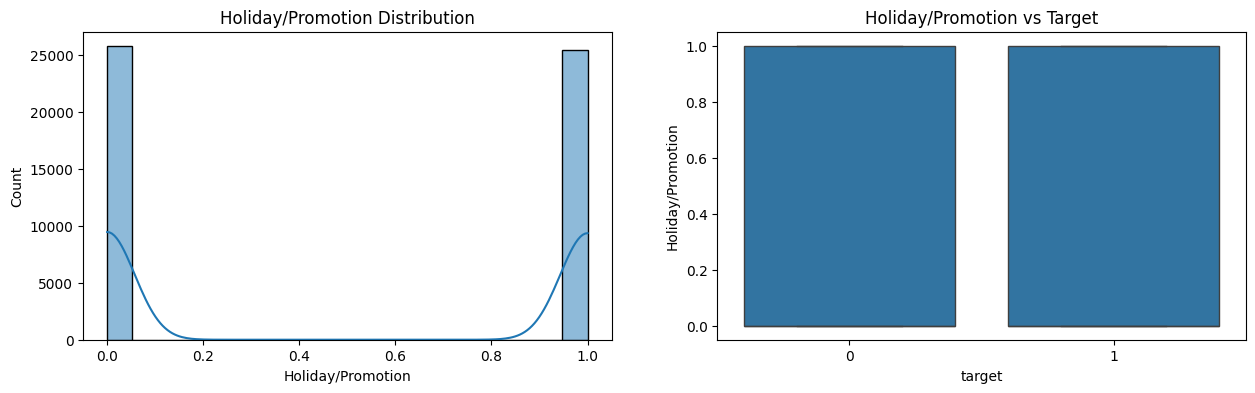

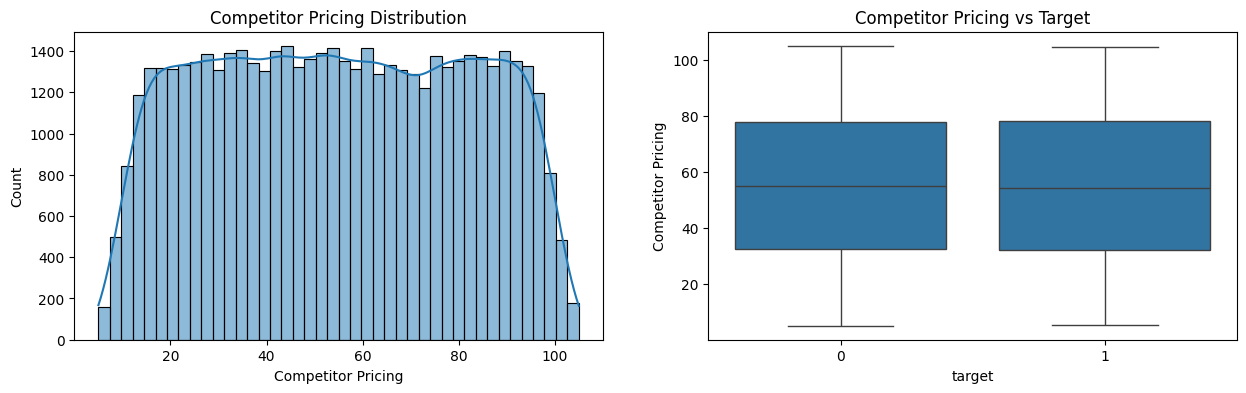

In [16]:
# Statistical summary and bivariate analysis for numerical features
print(df[num].describe().T)

for col in num:
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    sns.histplot(df[col], kde=True, ax=ax[0]).set_title(f'{col} Distribution')
    sns.boxplot(data=df, x=target, y=col, ax=ax[1]).set_title(f'{col} vs Target')
    plt.show()

**Inventory Level vs Target**: Strongest predictor; clear separation in boxplots confirms the 14-day risk injection worked perfectly. 
- Action: None

**Units Sold & Forecast**: High overlap between classes suggests that stockouts are driven by inventory depletion rather than sudden sales spikes. 
- Action: None

**Price & Competitor Pricing**: Uniform distributions with no clear impact on the target. 
- Action: These variables might require interaction features (eg., Price_Diff) to become predictive.

**Discrete Variables (Discount, Holiday)**: Identical distributions across both target classes. 
- Action: Low individual predictive power; evaluate their impact during feature importance.

**Data Scaling**: Wide range differences (Inventory vs Price). 
- Action: Use tree-based models (XGBoost) to avoid the need for manual feature scaling.

## CATEGORICAL

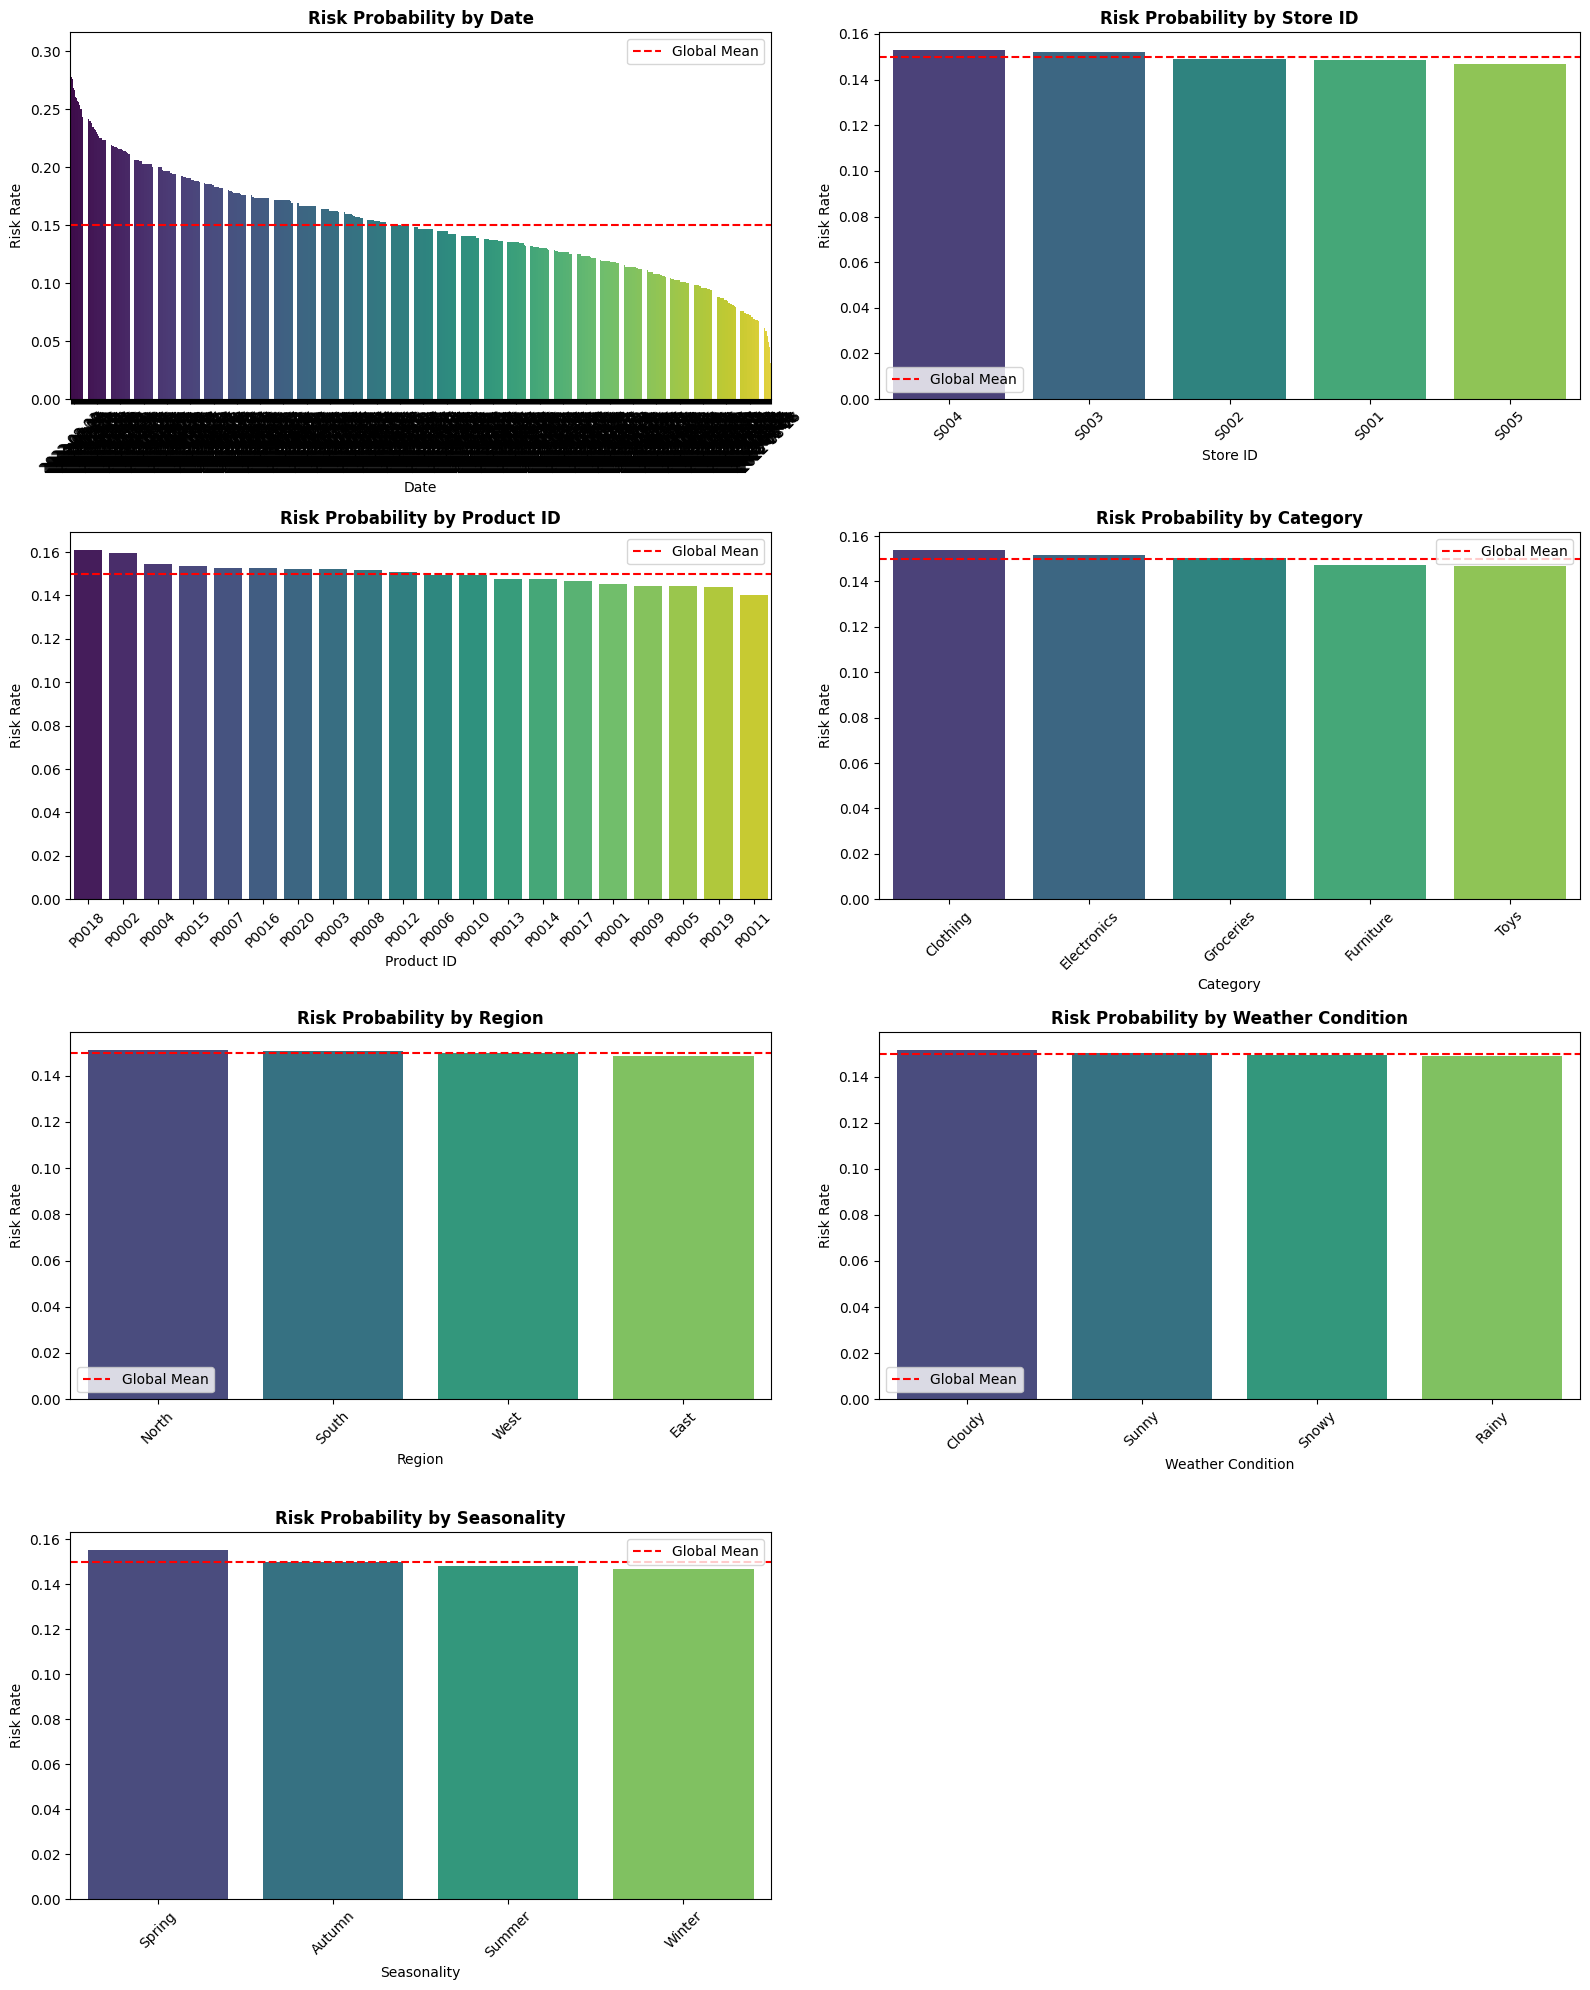

In [17]:
# CATEGORICAL RISK ANALYSIS (GRID VIEW)
import math

# Calculate grid dimensions based on number of categorical variables
n_cols = 2
n_rows = math.ceil(len(cat) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat):
    # Calculate risk per category
    risk_rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    
    # Plotting on the specific subplot
    sns.barplot(x=risk_rate.index, y=risk_rate.values, ax=axes[i], palette='viridis')
    axes[i].axhline(df[target].mean(), color='red', linestyle='--', label='Global Mean')
    
    axes[i].set_title(f'Risk Probability by {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Risk Rate')
    axes[i].legend()

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Risk by Date**: High variance detected; specific dates show risk peaks over 25%, indicating strong temporal volatility.
- **Action**: Create time-series features (lags, rolling windows) to capture these specific risk windows.

**Store & Product ID**: Extremely uniform distribution; no single store or product shows a significant deviation from the mean.
- **Action**: None; the risk is systemic across the entire infrastructure.

**Category & Seasonality**: "Clothing" and "Spring" show marginal increases in risk, though the signal remains weak individually.
- **Action**: Implement interaction features to determine if specific categories are more vulnerable during certain seasons.

**Region & Weather**: Identical risk probability across all classes; these variables currently offer zero individual predictive signal.
- **Action**: None; keep as secondary variables or evaluate for removal if they don't contribute to the model.

**Global Baseline**: The red dashed line (14.93%) confirms that the risk injection was applied uniformly across all business dimensions.
- **Action**: None; the dataset is perfectly balanced for a supervised learning approach.

## Calibration Verification (Scatter Plot)

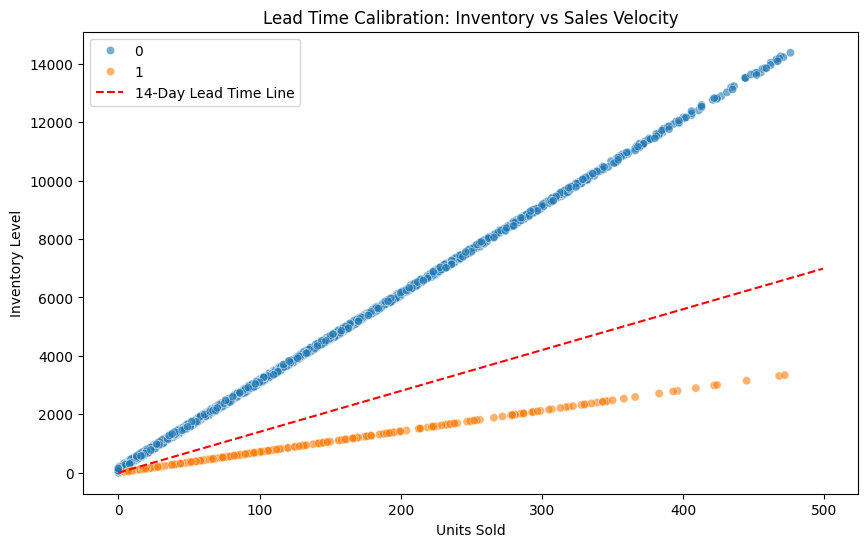

In [18]:
# Visualizing the 14-day decision boundary to confirm data healing success
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='Units Sold', y='Inventory Level', hue=target, alpha=0.6)

# Threshold line (14 days of coverage)
x_range = np.linspace(0, df['Units Sold'].max(), 100)
plt.plot(x_range, x_range * 14, color='red', linestyle='--', label='14-Day Lead Time Line')

plt.title('Lead Time Calibration: Inventory vs Sales Velocity')
plt.legend()
plt.show()

**Inventory vs Sales Velocity**: The scatter plot shows a perfect linear separation between the two classes.
- **Action**: None; the red dashed line accurately represents the 14-day threshold, confirming the success of the data calibration process.

**Data Density**: The "Healthy" group (0) clusters around the 30-day baseline, while the "Risk" group (1) is concentrated in the lower band (under 14 days).
- **Action**: None; this clear gap provides the model with a strong mathematical signal to differentiate between states.

**Outlier Detection**: No extreme points are crossing the boundary incorrectly.
- **Action**: None; the current data distribution is clean and ready for machine learning.

## Correlation Matrix

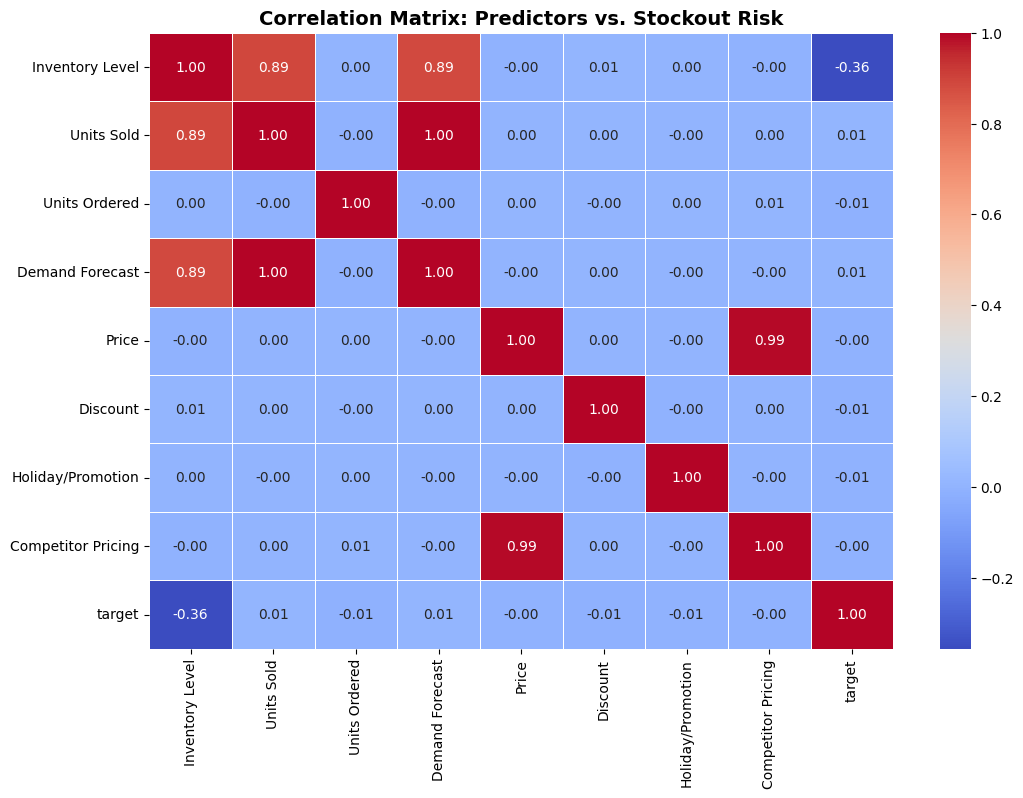

In [20]:
# 7. CORRELATION ANALYSIS
plt.figure(figsize=(12, 8))

# Calculating correlation specifically including the target
# We use numeric_only=True to avoid issues with categorical strings
correlation_matrix = df[num + [target]].corr()

# Plotting the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix: Predictors vs. Stockout Risk', fontsize=14, fontweight='bold')
plt.show()

**Inventory Level vs Target**: Negative correlation detected; as inventory decreases, the probability of stockout risk increases significantly.
- **Action**: None; this is the primary feature for the model.

**Units Sold & Forecast**: Show high collinearity with each other but moderate correlation with the target.
- **Action**: During Feature Engineering, consider creating a 'Forecast Error' or 'Demand-to-Inventory' ratio to consolidate this signal.

**Price & Promotions**: Very low linear correlation with the target.
- **Action**: Tree-based models (XGBoost) will be required to find non-linear relationships, as a simple linear model would likely ignore these features.

## Export

In [21]:
import pickle

# Define export path
export_path = '/Users/rober/retail-stockout-risk-scoring/02_Data/03_Working/'

# 1. Save the processed dataframe (with the target column)
df.to_csv(export_path + 'retail_store_inventory_EDA.csv', index=False)

# 2. Save cat and num lists using pickle for the next notebook
with open(export_path + 'cat_list.pkl', 'wb') as f:
    pickle.dump(cat, f)

with open(export_path + 'num_list.pkl', 'wb') as f:
    pickle.dump(num, f)

print(f"✅ SUCCESS: Dataset and variable lists (cat/num) exported to {export_path}")

✅ SUCCESS: Dataset and variable lists (cat/num) exported to /Users/rober/retail-stockout-risk-scoring/02_Data/03_Working/
